# Retailrocket E-commerce Funnel Analysis
## Notebook 01 — Data Cleaning and Exploratory Data Analysis

### Цель ноутбука
В этом ноутбуке выполняется:
- загрузка event-level данных Retailrocket
- первичная проверка структуры и качества данных
- очистка событий
- базовый exploratory data analysis
- подготовка данных для дальнейшего анализа воронки

### Основная таблица
Используется файл `events.csv`, содержащий:
- `timestamp` — время события
- `visitorid` — идентификатор пользователя
- `event` — тип события
- `itemid` — товар
- `transactionid` — идентификатор транзакции для событий покупки

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
events = pd.read_csv('data/events.csv')
events.head(5)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [7]:
events.describe(include='all')

,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


In [8]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


In [9]:
summary = pd.DataFrame({
    "dtype": events.dtypes.astype(str),
    "missing_count": events.isna().sum(),
    "missing_pct": (events.isna().sum() / len(events) * 100).round(2),
    "n_unique": events.nunique()
})
summary

,dtype,missing_count,missing_pct,n_unique
timestamp,int64,0,0.00,2750455
visitorid,int64,0,0.00,1407580
event,str,0,0.00,3
itemid,int64,0,0.00,235061
transactionid,float64,2733644,99.19,17672


## 2. Проверка качества данных

На этом этапе проверяются:
- полные дубликаты
- распределение событий
- уникальные пользователи и товары
- корректность поля `transactionid`

In [10]:
full_duplicates = events.duplicated().sum()
print("Полных дубликатов:", full_duplicates)

Полных дубликатов: 460


In [11]:
if full_duplicates > 0:
    display(events[events.duplicated()].head())

,timestamp,visitorid,event,itemid,transactionid
22404,1433180781440,1045411,addtocart,379647,NaN
34465,1433274223925,366538,addtocart,252068,NaN
39738,1433265100661,198153,addtocart,48715,NaN
41774,1433270868154,1268755,view,60980,NaN
42469,1433277134682,555487,addtocart,397642,NaN


In [12]:
events["event"].value_counts(dropna=False)

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [13]:
events["event"].value_counts(normalize=True).mul(100).round(2)

event
view           96.67
addtocart       2.52
transaction     0.81
Name: proportion, dtype: float64

In [14]:
print("Уникальных пользователей:", f"{events['visitorid'].nunique():,}")
print("Уникальных товаров:", f"{events['itemid'].nunique():,}")

Уникальных пользователей: 1,407,580
Уникальных товаров: 235,061


## 3. Работа со временем

Поле `timestamp` хранится в формате Unix time в миллисекундах.  
Преобразуем его в datetime и создадим дополнительные временные признаки.

In [15]:
events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms")
events["event_date"] = events["event_time"].dt.date
events["event_week"] = events["event_time"].dt.to_period("W").astype(str)
events["event_month"] = events["event_time"].dt.to_period("M").astype(str)
events["event_hour"] = events["event_time"].dt.hour
events["event_dayofweek"] = events["event_time"].dt.day_name()

In [16]:
print("Минимальная дата:", events["event_time"].min())
print("Максимальная дата:", events["event_time"].max())

Минимальная дата: 2015-05-03 03:00:04.384000
Максимальная дата: 2015-09-18 02:59:47.788000


In [17]:
transaction_check = events.groupby("event")["transactionid"].agg(
    total_rows="size",
    non_null_transactions=lambda x: x.notna().sum(),
    null_transactions=lambda x: x.isna().sum()
)
transaction_check

,total_rows,non_null_transactions,null_transactions
event,,,
addtocart,69332,0,69332
transaction,22457,22457,0
view,2664312,0,2664312


In [18]:
print(
    "Доля пропусков transactionid у transaction:",
    round(events.loc[events["event"] == "transaction", "transactionid"].isna().mean(), 4)
)

Доля пропусков transactionid у transaction: 0.0


## 4. Очистка данных

На этом этапе:
- удаляются полные дубликаты
- приводятся типы данных
- формируется очищенная таблица `events_clean`

In [19]:
events_clean = events.copy()
events_clean = events_clean.drop_duplicates().reset_index(drop=True)
events_clean["visitorid"] = events_clean["visitorid"].astype("int64")
events_clean["itemid"] = events_clean["itemid"].astype("int64")
events_clean["transactionid"] = events_clean["transactionid"].astype("Int64")
print("Размер очищенной таблицы:", events_clean.shape)
events_clean.head()

Размер очищенной таблицы: (2755641, 11)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_week,event_month,event_hour,event_dayofweek
0,1433221332117,257597,view,355908,<NA>,2015-06-02 05:02:12.117,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
1,1433224214164,992329,view,248676,<NA>,2015-06-02 05:50:14.164,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
2,1433221999827,111016,view,318965,<NA>,2015-06-02 05:13:19.827,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
3,1433221955914,483717,view,253185,<NA>,2015-06-02 05:12:35.914,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
4,1433221337106,951259,view,367447,<NA>,2015-06-02 05:02:17.106,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday


In [20]:
clean_summary = pd.DataFrame({
    "dtype": events_clean.dtypes.astype(str),
    "missing_count": events_clean.isna().sum(),
    "missing_pct": (events_clean.isna().sum() / len(events_clean) * 100).round(2),
    "n_unique": events_clean.nunique()
})
clean_summary

,dtype,missing_count,missing_pct,n_unique
timestamp,int64,0,0.00,2750455
visitorid,int64,0,0.00,1407580
event,str,0,0.00,3
itemid,int64,0,0.00,235061
transactionid,Int64,2733184,99.19,17672
event_time,datetime64[ms],0,0.00,2750455
event_date,object,0,0.00,139
event_week,str,0,0.00,21
event_month,str,0,0.00,5
event_hour,int32,0,0.00,24


## 5. Exploratory Data Analysis

Далее анализируется:
- распределение типов событий
- динамика событий во времени
- активность пользователей
- базовые top-items метрики

In [21]:
event_counts = events_clean["event"].value_counts().sort_values(ascending=False)
event_counts

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

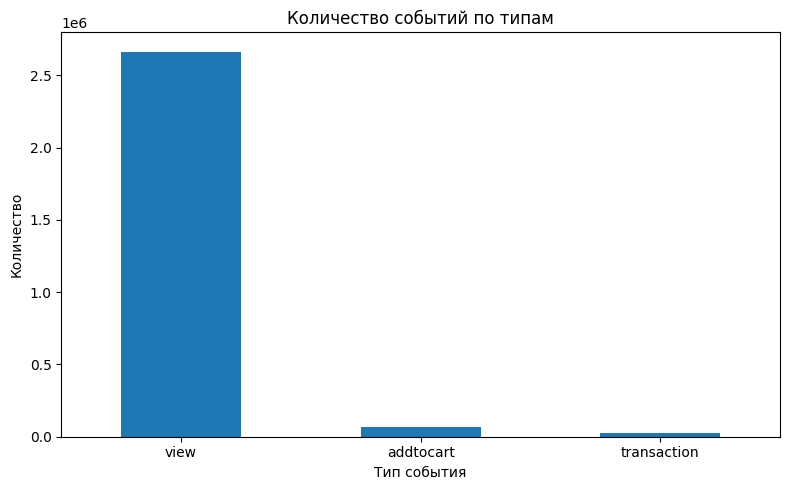

In [24]:
plt.figure(figsize=(8, 5))
event_counts.plot(kind="bar")
plt.title("Количество событий по типам")
plt.xlabel("Тип события")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
users_by_event = (
    events_clean.groupby("event")["visitorid"]
    .nunique()
    .sort_values(ascending=False)
)
users_by_event

event
view           1404179
addtocart        37722
transaction      11719
Name: visitorid, dtype: int64

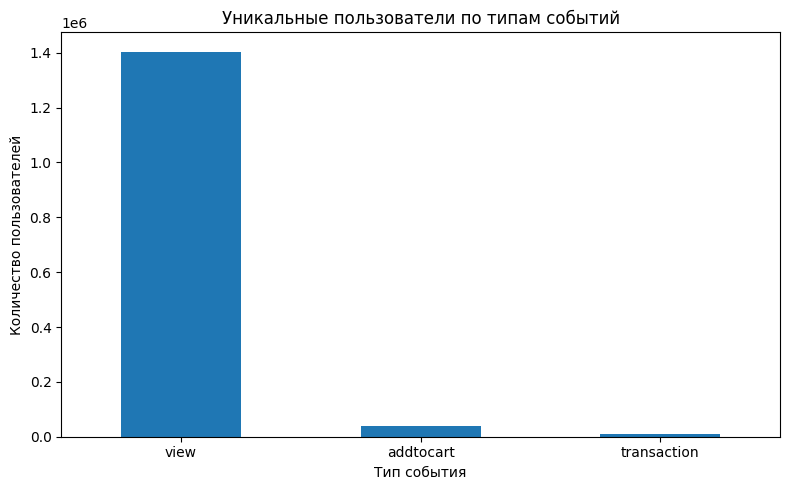

In [26]:
plt.figure(figsize=(8, 5))
users_by_event.plot(kind="bar")
plt.title("Уникальные пользователи по типам событий")
plt.xlabel("Тип события")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
events_per_day = (
    events_clean.groupby("event_date")
    .size()
    .reset_index(name="events_cnt")
)
events_per_day.head()

,event_date,events_cnt
0,2015-05-03,13682
1,2015-05-04,19413
2,2015-05-05,23011
3,2015-05-06,23920
4,2015-05-07,23157


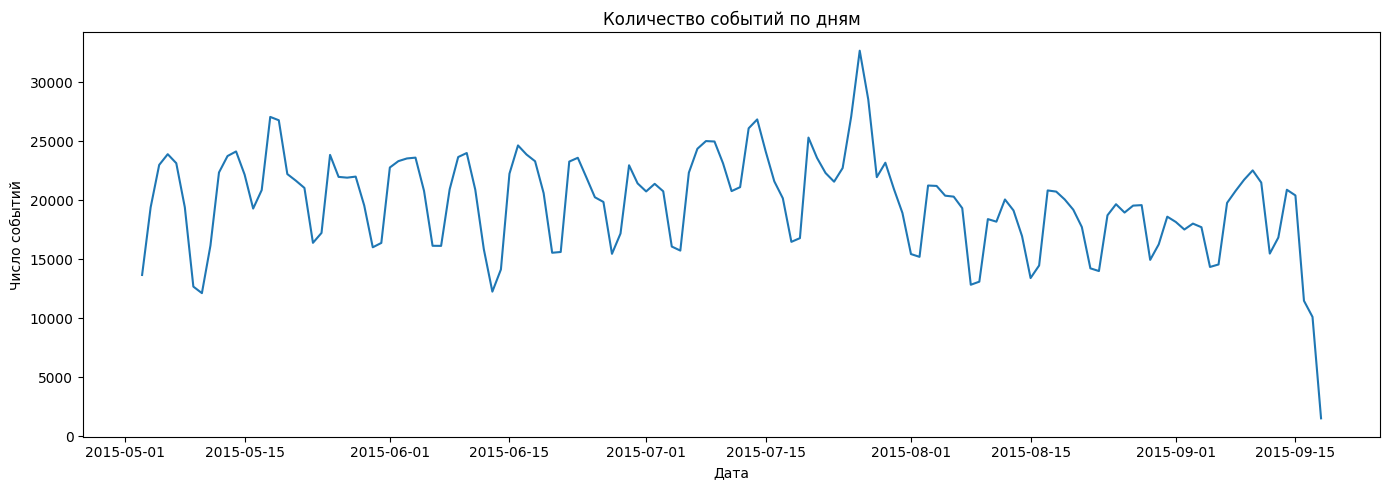

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(events_per_day["event_date"], events_per_day["events_cnt"])
plt.title("Количество событий по дням")
plt.xlabel("Дата")
plt.ylabel("Число событий")
plt.tight_layout()
plt.show()

In [29]:
events_by_day_type = (
    events_clean.groupby(["event_date", "event"])
    .size()
    .unstack(fill_value=0)
)
events_by_day_type.head()

event,addtocart,transaction,view
event_date,,,
2015-05-03,296,83,13303
2015-05-04,578,154,18681
2015-05-05,561,225,22225
2015-05-06,647,258,23015
2015-05-07,572,217,22368


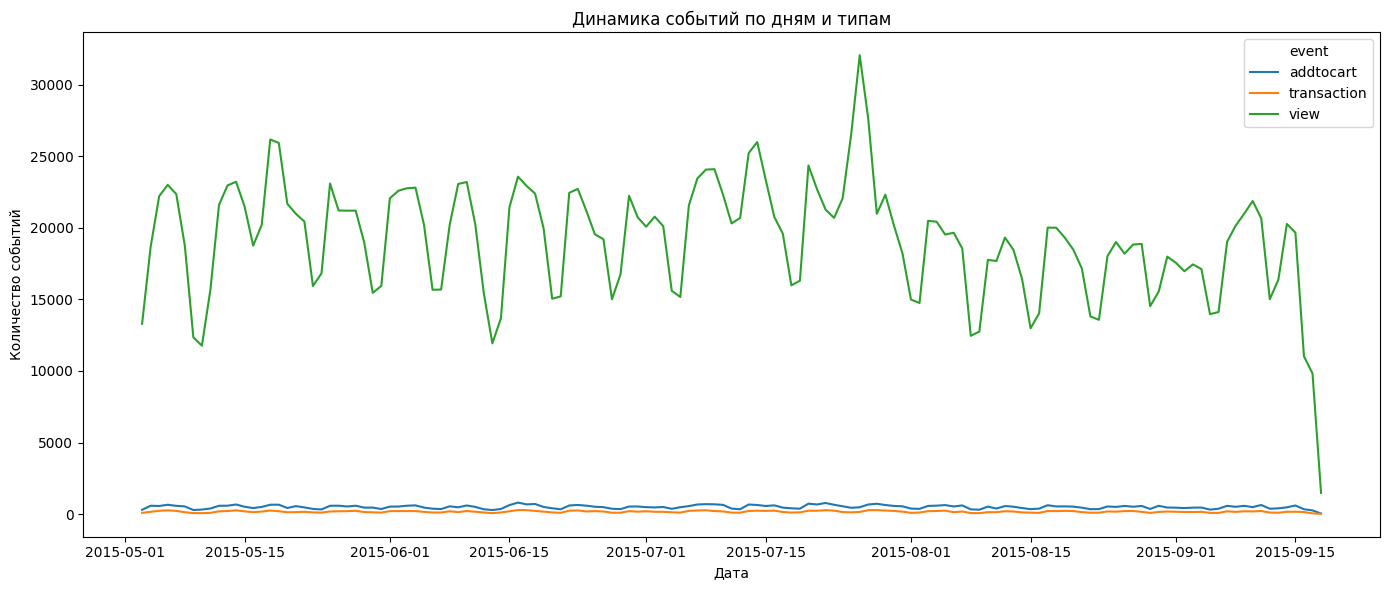

In [30]:
events_by_day_type.plot(figsize=(14, 6))
plt.title("Динамика событий по дням и типам")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.tight_layout()
plt.show()

In [31]:
users_per_day = (
    events_clean.groupby("event_date")["visitorid"]
    .nunique()
    .reset_index(name="unique_users")
)
users_per_day.head()

,event_date,unique_users
0,2015-05-03,7865
1,2015-05-04,11019
2,2015-05-05,13084
3,2015-05-06,13687
4,2015-05-07,13086


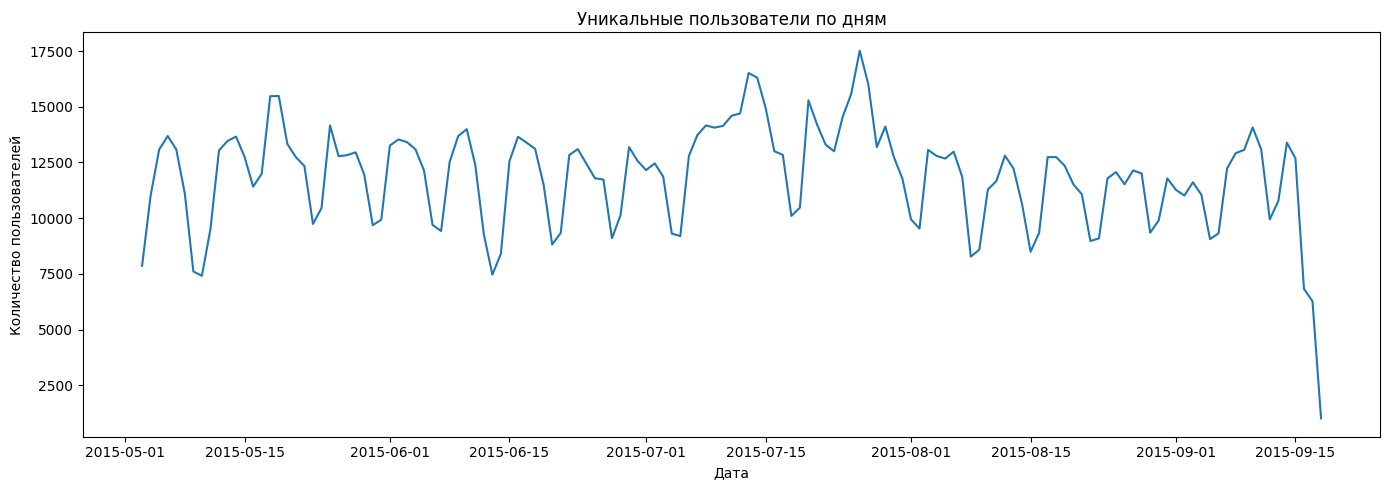

In [32]:
plt.figure(figsize=(14, 5))
plt.plot(users_per_day["event_date"], users_per_day["unique_users"])
plt.title("Уникальные пользователи по дням")
plt.xlabel("Дата")
plt.ylabel("Количество пользователей")
plt.tight_layout()
plt.show()

In [33]:
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
events_by_weekday = (
    events_clean["event_dayofweek"]
    .value_counts()
    .reindex(day_order)
)
events_by_weekday

event_dayofweek
Monday       439738
Tuesday      447006
Wednesday    431059
Thursday     418672
Friday       379624
Saturday     305167
Sunday       334375
Name: count, dtype: int64

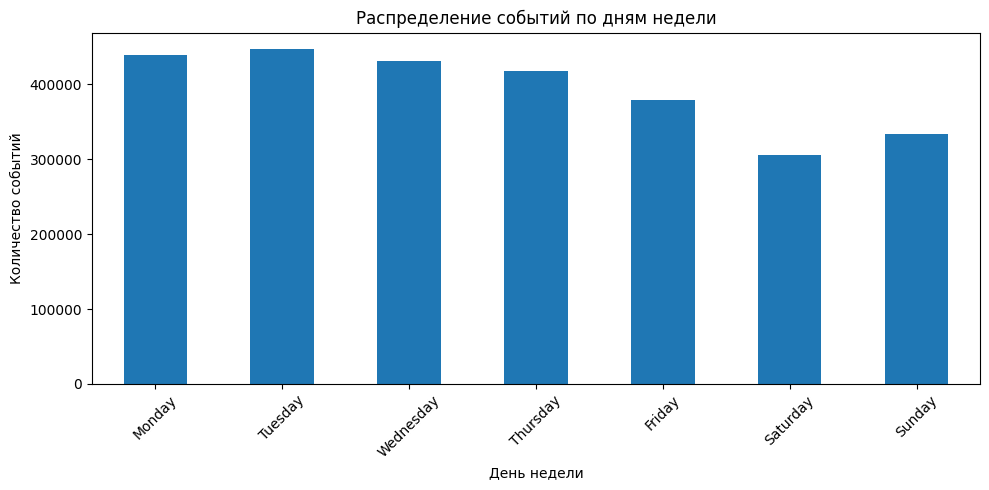

In [34]:
plt.figure(figsize=(10, 5))
events_by_weekday.plot(kind="bar")
plt.title("Распределение событий по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
events_by_hour = (
    events_clean["event_hour"]
    .value_counts()
    .sort_index()
)
events_by_hour

event_hour
0     144278
1     140673
2     145854
3     150831
4     147153
5     119558
6      76965
7      43936
8      25304
9      17905
10     16405
11     20328
12     31479
13     51084
14     81813
15    129074
16    161755
17    179611
18    181166
19    183324
20    187890
21    184272
22    175931
23    159052
Name: count, dtype: int64

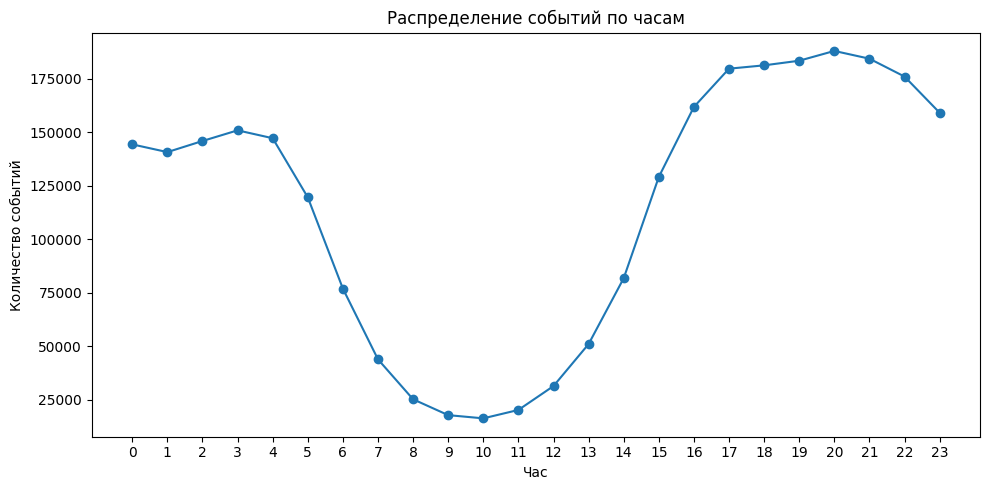

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(events_by_hour.index, events_by_hour.values, marker="o")
plt.title("Распределение событий по часам")
plt.xlabel("Час")
plt.ylabel("Количество событий")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [37]:
top_viewed_items = (
    events_clean.loc[events_clean["event"] == "view", "itemid"]
    .value_counts()
    .head(10)
)
top_viewed_items

itemid
187946    3410
461686    2538
5411      2325
370653    1854
219512    1740
298009    1642
96924     1633
309778    1565
257040    1531
384302    1528
Name: count, dtype: int64

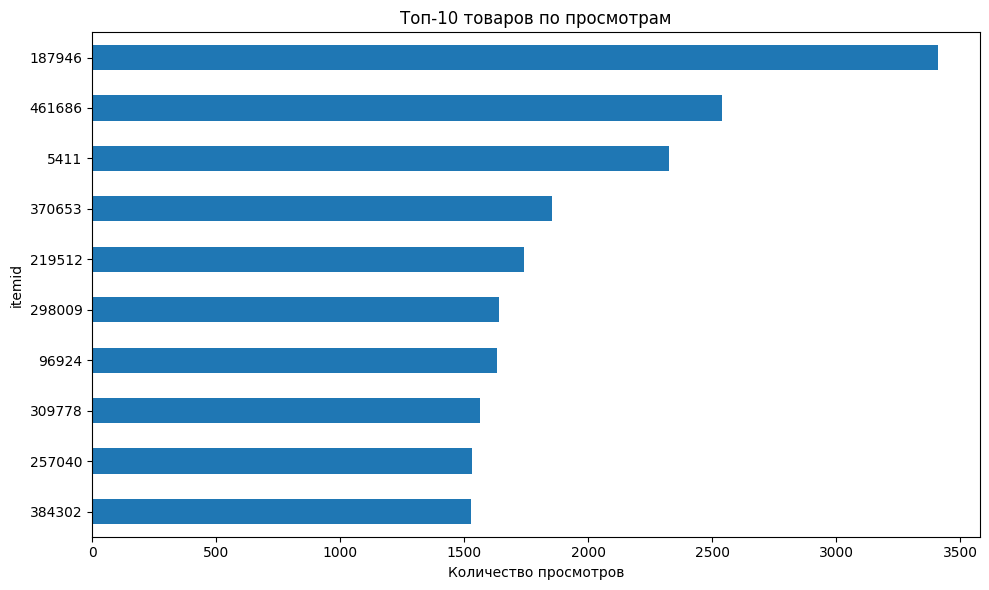

In [38]:
plt.figure(figsize=(10, 6))
top_viewed_items.sort_values().plot(kind="barh")
plt.title("Топ-10 товаров по просмотрам")
plt.xlabel("Количество просмотров")
plt.ylabel("itemid")
plt.tight_layout()
plt.show()

In [39]:
top_cart_items = (
    events_clean.loc[events_clean["event"] == "addtocart", "itemid"]
    .value_counts()
    .head(10)
)
top_cart_items

itemid
461686    304
312728    161
409804    152
320130    141
29196     135
7943       97
48030      95
441852     90
445351     89
257040     89
Name: count, dtype: int64

In [40]:
top_transaction_items = (
    events_clean.loc[events_clean["event"] == "transaction", "itemid"]
    .value_counts()
    .head(10)
)
top_transaction_items

itemid
461686    133
119736     97
213834     92
7943       46
312728     46
445351     45
48030      41
420960     38
248455     38
17478      37
Name: count, dtype: int64

In [41]:
eda_overview = pd.DataFrame({
    "metric": [
        "rows",
        "unique_users",
        "unique_items",
        "date_min",
        "date_max",
        "views",
        "addtocart",
        "transactions"
    ],
    "value": [
        len(events_clean),
        events_clean["visitorid"].nunique(),
        events_clean["itemid"].nunique(),
        events_clean["event_time"].min(),
        events_clean["event_time"].max(),
        (events_clean["event"] == "view").sum(),
        (events_clean["event"] == "addtocart").sum(),
        (events_clean["event"] == "transaction").sum()
    ]
})
eda_overview

,metric,value
0,rows,2755641
1,unique_users,1407580
2,unique_items,235061
3,date_min,2015-05-03 03:00:04.384000
4,date_max,2015-09-18 02:59:47.788000
5,views,2664218
6,addtocart,68966
7,transactions,22457


In [43]:
events_clean.to_csv('data/events_clean.csv', index=False)

## 6. Промежуточные выводы

По итогам первичного анализа можно сделать следующие выводы:

1. Датасет представляет собой event-level лог пользовательского поведения в e-commerce
2. Основную часть событий составляют просмотры товаров (`view`), тогда как `addtocart` и `transaction` встречаются значительно реже
3. Данные покрывают несколько месяцев активности и подходят для анализа динамики поведения во времени
4. Структура таблицы позволяет строить пользовательскую воронку `view → addtocart → transaction`
5. На следующем этапе можно переходить к расчету базовой и строгой воронки, а также к анализу времени до покупки